<a href="https://colab.research.google.com/github/snwCat/mi_hazi3/blob/main/mi_hazi3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Adatok beolvasása

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Adatok beolvasása
df = pd.read_csv("corvinus_mi2026-g25.csv")

# Felesleges index oszlop (Unnamed: 0) eldobása, ha létezik
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print("Adathalmaz mérete:", df.shape)

# Hiányzó értékek százalékos aránya oszloponként
missing_percentages = (df.isna().sum() / len(df) * 100).round(2)
print("\nHiányzó értékek aránya (%):\n", missing_percentages)

Adathalmaz mérete: (2108, 9)

Hiányzó értékek aránya (%):
 title             0.00
Movie_Rating      0.00
No_of_Ratings     0.00
Format            0.00
ReleaseYear       1.85
MPAA_Rating      34.63
Directed_By       3.08
Starring          0.05
Price            52.04
dtype: float64


Adatfeldolgozás, tisztítás

In [23]:
df_clean = df.copy()

# Kategoriális oszlopok pótlása "Ismeretlen" értékkel
cat_cols = ["Format", "MPAA_Rating", "Directed_By", "Starring"]
df_clean[cat_cols] = df_clean[cat_cols].fillna("Ismeretlen")

# Numerikus oszlopok pótlása mediánnal
#az átlaggal ellentétben – nem torzítják el a kiugróan magas vagy alacsony extrém értékek
num_cols = ["No_of_Ratings", "ReleaseYear", "Price"]
imputer = SimpleImputer(strategy="median")
df_clean[num_cols] = imputer.fit_transform(df_clean[num_cols])

# Értékelésszám logaritmizálása az extrém különbségek tompítására
#A logaritmizálás "összenyomja" és normalizálja ezt az óriási különbséget, így a modell sokkal stabilabban és pontosabban tud tanulni az adatokból.
df_clean["log_No_of_Ratings"] = np.log1p(df_clean["No_of_Ratings"])

print("Adatok sikeresen megtisztítva.")

Adatok sikeresen megtisztítva.


Kérdések megválaszolása

Ismeretlen rendezőjű filmek száma: 65 db
Különböző rendezők száma: 1377 fő
Átlagos filmszám rendezőnként: 1.48 db
Medián filmszám rendezőnként: 1 db
Rendezőnkénti filmszám szórása: 1.24 db

Különböző színészek száma: 3617 fő
Legtöbb filmben szereplő színész: Tom Cruise (17 film)

Filmek átlag-értékelése: 4.48
Értékelések szórása: 0.26

Pearson-korreláció az Értékelésszám és a Pontszám között: 0.2509
Pearson-korreláció a Log(Értékelésszám) és a Pontszám között: 0.2933


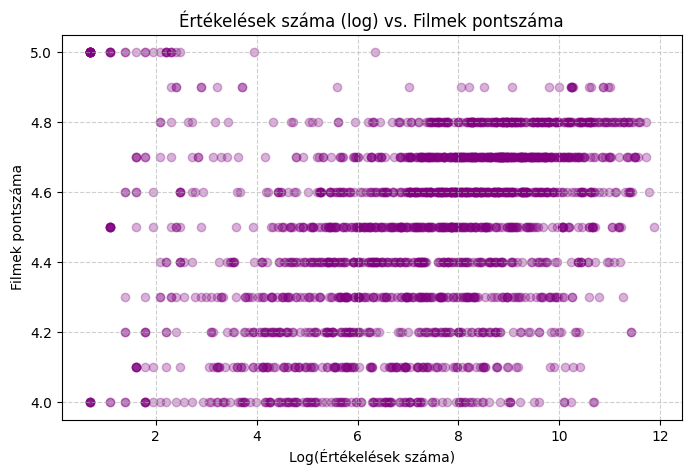

In [24]:
# Szűrés, hogy az imputált "Ismeretlen" ne torzítsa a statisztikákat
df_valid_dir = df_clean[df_clean["Directed_By"] != "Ismeretlen"]
df_valid_star = df_clean[df_clean["Starring"] != "Ismeretlen"]

# 1-2. Kérdés: Rendezők statisztikái
dir_counts = df_valid_dir.groupby("Directed_By")["title"].count()
ismeretlen_db = df_clean["Directed_By"].value_counts().get("Ismeretlen", 0)
print(f"Ismeretlen rendezőjű filmek száma: {ismeretlen_db} db")
print(f"Különböző rendezők száma: {dir_counts.index.nunique()} fő")
print(f"Átlagos filmszám rendezőnként: {dir_counts.mean():.2f} db")
print(f"Medián filmszám rendezőnként: {dir_counts.median():.0f} db")
print(f"Rendezőnkénti filmszám szórása: {dir_counts.std():.2f} db")

# 3. Kérdés: Színészek statisztikái
actors_exploded = df_valid_star["Starring"].str.split(",").explode().str.strip()
print(f"\nKülönböző színészek száma: {actors_exploded.nunique()} fő")
print(f"Legtöbb filmben szereplő színész: {actors_exploded.value_counts().idxmax()} ({actors_exploded.value_counts().max()} film)")

# 4. Kérdés: Értékelések statisztikái
print(f"\nFilmek átlag-értékelése: {df_clean['Movie_Rating'].mean():.2f}")
print(f"Értékelések szórása: {df_clean['Movie_Rating'].std():.2f}")

# 5. Kérdés: Prediktálja-e az értékelésszám a pontszámot? (Korreláció)
corr_eredeti = df_clean["No_of_Ratings"].corr(df_clean["Movie_Rating"])
corr_log = df_clean["log_No_of_Ratings"].corr(df_clean["Movie_Rating"])
print(f"\nPearson-korreláció az Értékelésszám és a Pontszám között: {corr_eredeti:.4f}")
print(f"Pearson-korreláció a Log(Értékelésszám) és a Pontszám között: {corr_log:.4f}")

# Ábra a kapcsolat szemléltetésére
plt.figure(figsize=(8, 5))
plt.scatter(df_clean["log_No_of_Ratings"], df_clean["Movie_Rating"], alpha=0.3, color='purple')
plt.title("Értékelések száma (log) vs. Filmek pontszáma")
plt.xlabel("Log(Értékelések száma)")
plt.ylabel("Filmek pontszáma")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Modellezés

In [25]:
# Dummy kódolás a top 5 kategóriával
top_mpaa = df_clean['MPAA_Rating'].value_counts().nlargest(5).index
df_clean['MPAA_Rating'] = df_clean['MPAA_Rating'].where(df_clean['MPAA_Rating'].isin(top_mpaa), 'Egyéb')
df_encoded = pd.get_dummies(df_clean[["log_No_of_Ratings", "ReleaseYear", "Price", "MPAA_Rating"]], drop_first=True)

X = df_encoded
y = df_clean["Movie_Rating"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Modell betanítva.")
print("Ez a kódrészlet felkészíti az adatokat a gép számára, és betanítja a prediktív modellt. Először a korhatárokat (MPAA_Rating) úgynevezett dummy változókká alakítja (0-k és 1-esek), mert a modell csak számokkal tud számolni, nem szöveggel. Ezután az adatokat skálázza (StandardScaler), hogy a különböző nagyságrendű változók – például az évek és az árak – azonos súllyal essenek latba. Majd 80%-20% arányban szétválasztja az adatokat tanító és tesztelő halmazra. Végül ezen a tanítóhalmazon betanít egy robusztus, fa-alapú algoritmust (Random Forest Regresszort), amely így megtanulja megjósolni a filmek értékelését a betáplált változókból.")

Modell betanítva.
Ez a kódrészlet felkészíti az adatokat a gép számára, és betanítja a prediktív modellt. Először a korhatárokat (MPAA_Rating) úgynevezett dummy változókká alakítja (0-k és 1-esek), mert a modell csak számokkal tud számolni, nem szöveggel. Ezután az adatokat skálázza (StandardScaler), hogy a különböző nagyságrendű változók – például az évek és az árak – azonos súllyal essenek latba. Majd 80%-20% arányban szétválasztja az adatokat tanító és tesztelő halmazra. Végül ezen a tanítóhalmazon betanít egy robusztus, fa-alapú algoritmust (Random Forest Regresszort), amely így megtanulja megjósolni a filmek értékelését a betáplált változókból.


Kiértékelés

In [26]:
preds = rf_model.predict(X_test)
print(f"R² (Magyarázóerő): {r2_score(y_test, preds):.4f}")
print(f"RMSE (Átlagos négyzetes hiba): {np.sqrt(mean_squared_error(y_test, preds)):.4f}")

R² (Magyarázóerő): 0.3911
RMSE (Átlagos négyzetes hiba): 0.2011
